Bibliotheken importieren & Quelle prüfen

In [1]:
import requests
import pandas as pd
from zipfile import ZipFile
from io import BytesIO

# Beispiel-URL für einen Monat (z.B. Juli 2023 für Jersey City, da diese etwas kleiner ist zum Testen)
url = "https://s3.amazonaws.com/tripdata/JC-202307-citibike-tripdata.csv.zip"

# 1. Prüfen, ob die Quelle antwortet (Status 200 = OK)
print(f"Prüfe Erreichbarkeit von: {url}")
response_check = requests.head(url)

if response_check.status_code == 200:
    print("✅ Status 200: Die Datenquelle ist erreichbar!")
else:
    print(f"❌ Fehler: Server antwortet mit Status Code {response_check.status_code}")

Prüfe Erreichbarkeit von: https://s3.amazonaws.com/tripdata/JC-202307-citibike-tripdata.csv.zip
✅ Status 200: Die Datenquelle ist erreichbar!


Daten herunterladen und in Pandas laden

In [2]:
# 2. Daten herunterladen
print("Lade Daten herunter (das kann ein paar Sekunden dauern)...")
response = requests.get(url)

# ZIP-Datei im Arbeitsspeicher öffnen
print("Entpacke ZIP-Datei im Arbeitsspeicher...")
zip_file = ZipFile(BytesIO(response.content))

# Den Namen der CSV-Datei im Archiv herausfinden
csv_filename = [name for name in zip_file.namelist() if name.endswith('.csv')][0]
print(f"Lese CSV-Datei: {csv_filename}")

# In Pandas DataFrame laden (low_memory=False verhindert Typen-Warnungen bei großen Dateien)
df_citi = pd.read_csv(zip_file.open(csv_filename), low_memory=False)

print(f"✅ Daten erfolgreich geladen! Es sind {len(df_citi):,} Zeilen.")

Lade Daten herunter (das kann ein paar Sekunden dauern)...
Entpacke ZIP-Datei im Arbeitsspeicher...
Lese CSV-Datei: JC-202307-citibike-tripdata.csv
✅ Daten erfolgreich geladen! Es sind 106,608 Zeilen.


In [3]:
# 3. Erster Blick auf die Daten
print("Vorschau der ersten 5 Zeilen:")
display(df_citi.head())

print("\n" + "="*50 + "\n")

print("Struktur und Datentypen des DataFrames:")
df_citi.info()

Vorschau der ersten 5 Zeilen:


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,7A68381621C25F78,classic_bike,2023-07-17 17:16:34,2023-07-17 17:20:52,Astor Place,JC077,Communipaw & Berry Lane,JC084,40.719225,-74.071281,40.714358,-74.066611,member
1,0F814CA67B2FA120,classic_bike,2023-07-26 19:40:15,2023-07-26 19:44:37,Adams St & 2 St,HB407,9 St HBLR - Jackson St & 8 St,HB305,40.739727,-74.036866,40.747907,-74.038412,member
2,775A38967EBF5FB4,electric_bike,2023-07-01 12:12:22,2023-07-01 12:27:45,McGinley Square,JC055,Riverview Park,JC057,40.725340,-74.067622,40.744319,-74.043991,member
3,D93B742DCE1C1447,classic_bike,2023-07-20 19:10:18,2023-07-20 19:17:22,Baldwin at Montgomery,JC020,Brunswick St,JC023,40.723455,-74.064359,40.724176,-74.050656,member
4,AA7A6863B4B92169,electric_bike,2023-07-07 19:33:59,2023-07-07 19:58:17,Baldwin at Montgomery,JC020,Mama Johnson Field - 4 St & Jackson St,HB404,40.723659,-74.064194,40.743140,-74.040041,casual




Struktur und Datentypen des DataFrames:
<class 'pandas.DataFrame'>
RangeIndex: 106608 entries, 0 to 106607
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ride_id             106608 non-null  str    
 1   rideable_type       106608 non-null  str    
 2   started_at          106608 non-null  str    
 3   ended_at            106608 non-null  str    
 4   start_station_name  106601 non-null  str    
 5   start_station_id    106601 non-null  str    
 6   end_station_name    106216 non-null  str    
 7   end_station_id      106216 non-null  str    
 8   start_lat           106608 non-null  float64
 9   start_lng           106608 non-null  float64
 10  end_lat             106486 non-null  float64
 11  end_lng             106486 non-null  float64
 12  member_casual       106608 non-null  str    
dtypes: float64(4), str(9)
memory usage: 10.6 MB


Datentypen fixen und Fahrtdauer berechnen

In [4]:
# 4. Datentypen korrigieren und Fahrtdauer berechnen
print("Konvertiere Zeitstempel in echte Datetime-Objekte...")
df_citi['started_at'] = pd.to_datetime(df_citi['started_at'])
df_citi['ended_at'] = pd.to_datetime(df_citi['ended_at'])

# Fahrtdauer in Minuten berechnen (Endzeit minus Startzeit)
print("Berechne Fahrtdauer in Minuten...")
df_citi['duration_minutes'] = (df_citi['ended_at'] - df_citi['started_at']).dt.total_seconds() / 60

# Zeige statistische Kennzahlen der neuen Spalte
print("\nStatistische Zusammenfassung der Fahrtdauer:")
display(df_citi['duration_minutes'].describe().apply(lambda x: format(x, 'f'))) 
# (Tipp: .apply(...) verhindert, dass Pandas die Zahlen in wissenschaftlicher Notation wie 1.5e+03 anzeigt)

Konvertiere Zeitstempel in echte Datetime-Objekte...
Berechne Fahrtdauer in Minuten...

Statistische Zusammenfassung der Fahrtdauer:


count    106608.000000
mean         14.099787
std          61.582193
min          -0.016667
25%           4.333333
50%           6.866667
75%          11.566667
max        3849.783333
Name: duration_minutes, dtype: str

Wir werfen alles unter 1 Minute raus ("Fehlstarts": Jemand entsperrt ein Bike, merkt, dass der Reifen platt ist, etc., und stellt es nach 10 Sekunden wieder zurück).

Werfe alles über 24 Stunden (1440 Minuten) raus. (Gestohlen oder vergessen zu retounieren)

In [5]:
# 5. Ausreißer bei der Fahrtdauer entfernen
print(f"Anzahl Fahrten VOR der Bereinigung: {len(df_citi):,}")

# Wir behalten nur Fahrten, die zwischen 1 Minute und 24 Stunden (1440 Minuten) dauern
df_citi = df_citi[(df_citi['duration_minutes'] >= 1) & (df_citi['duration_minutes'] <= 1440)]

print(f"Anzahl Fahrten NACH der Bereinigung: {len(df_citi):,}")
print(f"Es wurden somit {106608 - len(df_citi):,} fehlerhafte Ausreißer entfernt.")

# Zur Kontrolle nochmal das Minimum und Maximum prüfen:
display(df_citi['duration_minutes'].describe().apply(lambda x: format(x, 'f')))

Anzahl Fahrten VOR der Bereinigung: 106,608
Anzahl Fahrten NACH der Bereinigung: 104,415
Es wurden somit 2,193 fehlerhafte Ausreißer entfernt.


count    104415.000000
mean         12.582945
std          33.566765
min           1.000000
25%           4.450000
50%           6.983333
75%          11.683333
max        1339.550000
Name: duration_minutes, dtype: str

Prüfung auf fehlende Daten (NaNs)

In [6]:
# 6. Fehlende Werte (NaNs) prüfen
print("Anzahl der fehlenden Werte pro Spalte:")
display(df_citi.isna().sum())

Anzahl der fehlenden Werte pro Spalte:


ride_id                 0
rideable_type           0
started_at              0
ended_at                0
start_station_name      7
start_station_id        7
end_station_name      270
end_station_id        270
start_lat               0
start_lng               0
end_lat                 2
end_lng                 2
member_casual           0
duration_minutes        0
dtype: int64

Unvollständige Zeilen löschen

In [7]:
# 7. Fehlende Werte (NaNs) behandeln
print(f"Zeilen VOR dem Löschen der NaNs: {len(df_citi):,}")

# Wir löschen alle Zeilen, in denen kritische IDs oder Koordinaten fehlen
kritische_spalten = ['start_station_id', 'end_station_id', 'end_lat', 'end_lng']
df_citi = df_citi.dropna(subset=kritische_spalten)

print(f"Zeilen NACH dem Löschen der NaNs: {len(df_citi):,}")

# Zur Kontrolle prüfen wir, ob jetzt alles sauber ist:
print("\nÜbrig gebliebene fehlende Werte:")
display(df_citi.isna().sum())

Zeilen VOR dem Löschen der NaNs: 104,415
Zeilen NACH dem Löschen der NaNs: 104,145

Übrig gebliebene fehlende Werte:


ride_id               0
rideable_type         0
started_at            0
ended_at              0
start_station_name    0
start_station_id      0
end_station_name      0
end_station_id        0
start_lat             0
start_lng             0
end_lat               0
end_lng               0
member_casual         0
duration_minutes      0
dtype: int64

Koordinatencheck: mit Hilfe einer Karte visualisieren

Erstelle Streudiagramm der Start-Stationen...


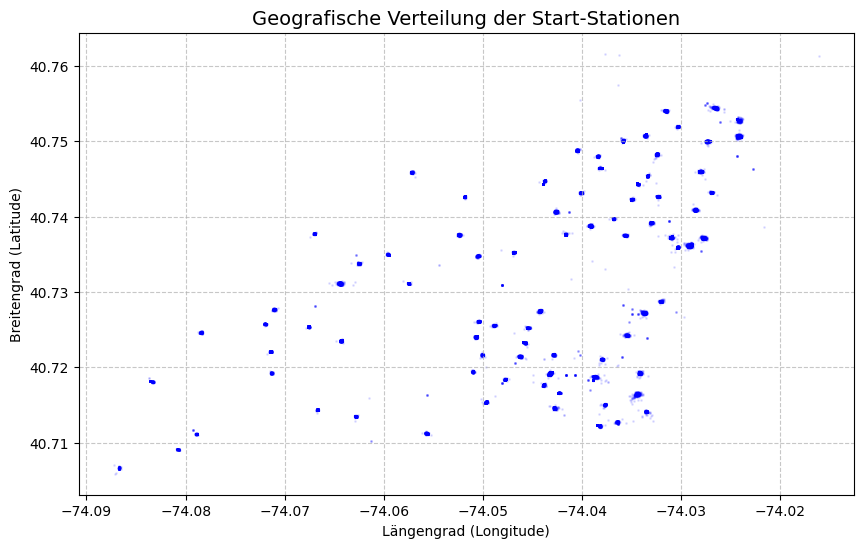


Min/Max Werte der Start-Koordinaten:


,start_lat,start_lng
min,40.705897,-74.087223
max,40.761599,-74.016154


In [8]:
import matplotlib.pyplot as plt

# 8. Geo-Daten auf Ausreißer prüfen
print("Erstelle Streudiagramm der Start-Stationen...")

plt.figure(figsize=(10, 6))
# Wir plotten Längengrad (X-Achse) gegen Breitengrad (Y-Achse)
# alpha=0.1 macht die Punkte leicht transparent, s=1 macht sie sehr klein
plt.scatter(df_citi['start_lng'], df_citi['start_lat'], alpha=0.1, s=1, color='blue')

plt.title('Geografische Verteilung der Start-Stationen', fontsize=14)
plt.xlabel('Längengrad (Longitude)')
plt.ylabel('Breitengrad (Latitude)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

# Ausgabe der exakten minimalen und maximalen Koordinaten
print("\nMin/Max Werte der Start-Koordinaten:")
display(df_citi[['start_lat', 'start_lng']].describe().loc[['min', 'max']])

In [9]:
# 9. Geo-Ausreißer (Null Island) filtern
print(f"Zeilen VOR dem Geo-Filter: {len(df_citi):,}")

# Wir filtern die Koordinaten auf den ungefähren Raum NY / NJ
df_citi = df_citi[
    (df_citi['start_lat'] > 40.0) & (df_citi['start_lat'] < 41.5) & 
    (df_citi['start_lng'] < -73.0) & (df_citi['start_lng'] > -74.5)
]

print(f"Zeilen NACH dem Geo-Filter: {len(df_citi):,}")

# Kontrolle: Wie sehen die Min/Max Werte jetzt aus?
print("\nBereinigte Min/Max Werte der Start-Koordinaten:")
display(df_citi[['start_lat', 'start_lng']].describe().loc[['min', 'max']])

Zeilen VOR dem Geo-Filter: 104,145
Zeilen NACH dem Geo-Filter: 104,145

Bereinigte Min/Max Werte der Start-Koordinaten:


,start_lat,start_lng
min,40.705897,-74.087223
max,40.761599,-74.016154


In [11]:
# 11. Inkonsistenzen bei Stationen aufdecken
print("Prüfe auf GPS-Jitter und Namensänderungen bei gleicher Station-ID...")

# Wir schauen uns an, wie viele verschiedene Namen und Koordinaten eine ID hat
station_check = df_citi.groupby('start_station_id').agg(
    anzahl_verschiedene_namen=('start_station_name', 'nunique'),
    anzahl_verschiedene_koordinaten=('start_lat', 'nunique'),
    beispiel_name=('start_station_name', 'first')
).sort_values('anzahl_verschiedene_koordinaten', ascending=False)

print("\nTop 5 Stationen mit den meisten unterschiedlichen GPS-Koordinaten:")
display(station_check.head())

# Zeige alle unterschiedlichen Namen für eine Station, falls es Namensänderungen gab
namens_chaos = station_check[station_check['anzahl_verschiedene_namen'] > 1]
if not namens_chaos.empty:
    print(f"\nEs gibt {len(namens_chaos)} Stationen, die unter der gleichen ID verschiedene Namen haben!")
else:
    print("\nGlück gehabt: In diesem Monat hat jede Station-ID exakt einen durchgehenden Namen.")

Prüfe auf GPS-Jitter und Namensänderungen bei gleicher Station-ID...

Top 5 Stationen mit den meisten unterschiedlichen GPS-Koordinaten:


,anzahl_verschiedene_namen,anzahl_verschiedene_koordinaten,beispiel_name
start_station_id,,,
HB102,1,1532,Hoboken Terminal - River St & Hudson Pl
JC115,1,1331,Grove St PATH
HB103,1,1086,South Waterfront Walkway - Sinatra Dr & 1 St
HB201,1,1080,12 St & Sinatra Dr N
JC109,1,956,Bergen Ave & Sip Ave



Glück gehabt: In diesem Monat hat jede Station-ID exakt einen durchgehenden Namen.


Erstelle visuelle Zusammenfassung (Prep Builder Style)...


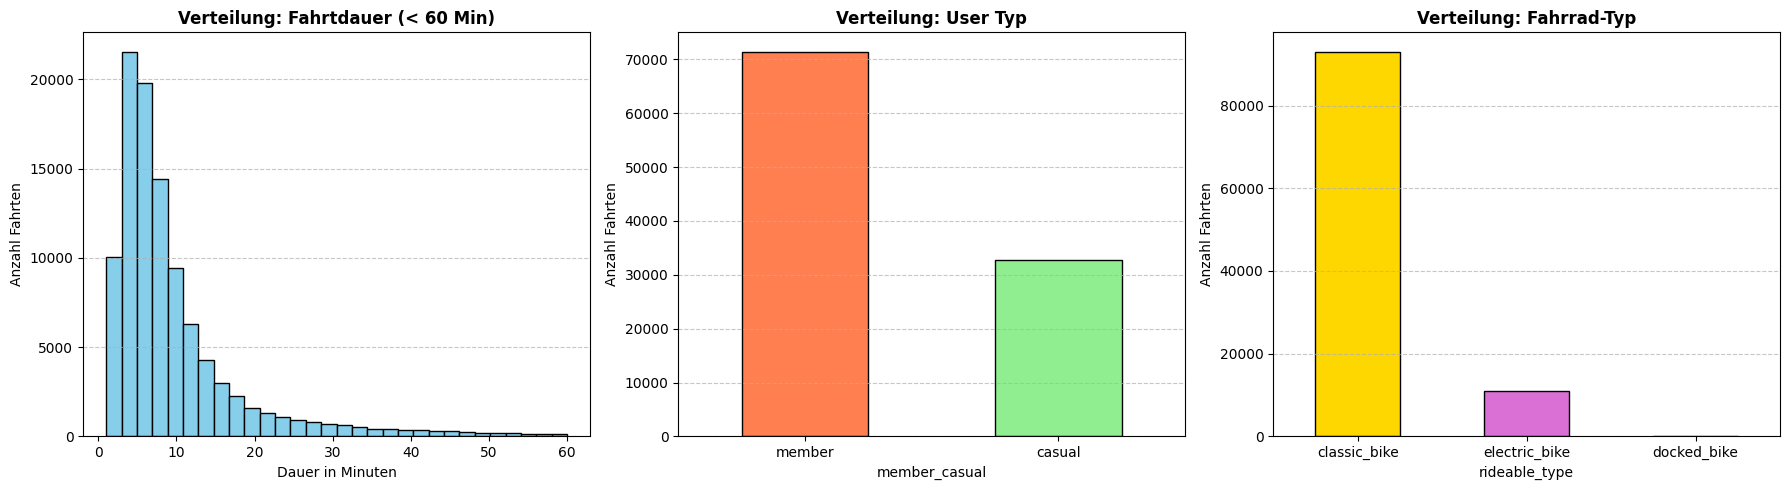

In [10]:
import matplotlib.pyplot as plt

print("Erstelle visuelle Zusammenfassung (Prep Builder Style)...")

# Wir erstellen ein Raster mit 1 Zeile und 3 Spalten für unsere Diagramme
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Verteilung der Fahrtdauer (Histogramm)
# Wir schauen uns nur Fahrten unter 60 Minuten an, da hier 99% der Daten liegen
df_citi[df_citi['duration_minutes'] < 60]['duration_minutes'].hist(bins=30, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Verteilung: Fahrtdauer (< 60 Min)', fontweight='bold')
axes[0].set_xlabel('Dauer in Minuten')
axes[0].set_ylabel('Anzahl Fahrten')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].grid(axis='x', visible=False)

# 2. Nutzertypen (Balkendiagramm)
df_citi['member_casual'].value_counts().plot(kind='bar', ax=axes[1], color=['coral', 'lightgreen'], edgecolor='black')
axes[1].set_title('Verteilung: User Typ', fontweight='bold')
axes[1].set_ylabel('Anzahl Fahrten')
axes[1].tick_params(axis='x', rotation=0) # Text waagerecht lassen
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# 3. Fahrradtypen (Balkendiagramm)
df_citi['rideable_type'].value_counts().plot(kind='bar', ax=axes[2], color=['gold', 'orchid', 'cyan'], edgecolor='black')
axes[2].set_title('Verteilung: Fahrrad-Typ', fontweight='bold')
axes[2].set_ylabel('Anzahl Fahrten')
axes[2].tick_params(axis='x', rotation=0)
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

# Layout optimieren und anzeigen
plt.tight_layout()
plt.show()

vollständige Data Profiling:

Generiere umfassendes Data Profiling...


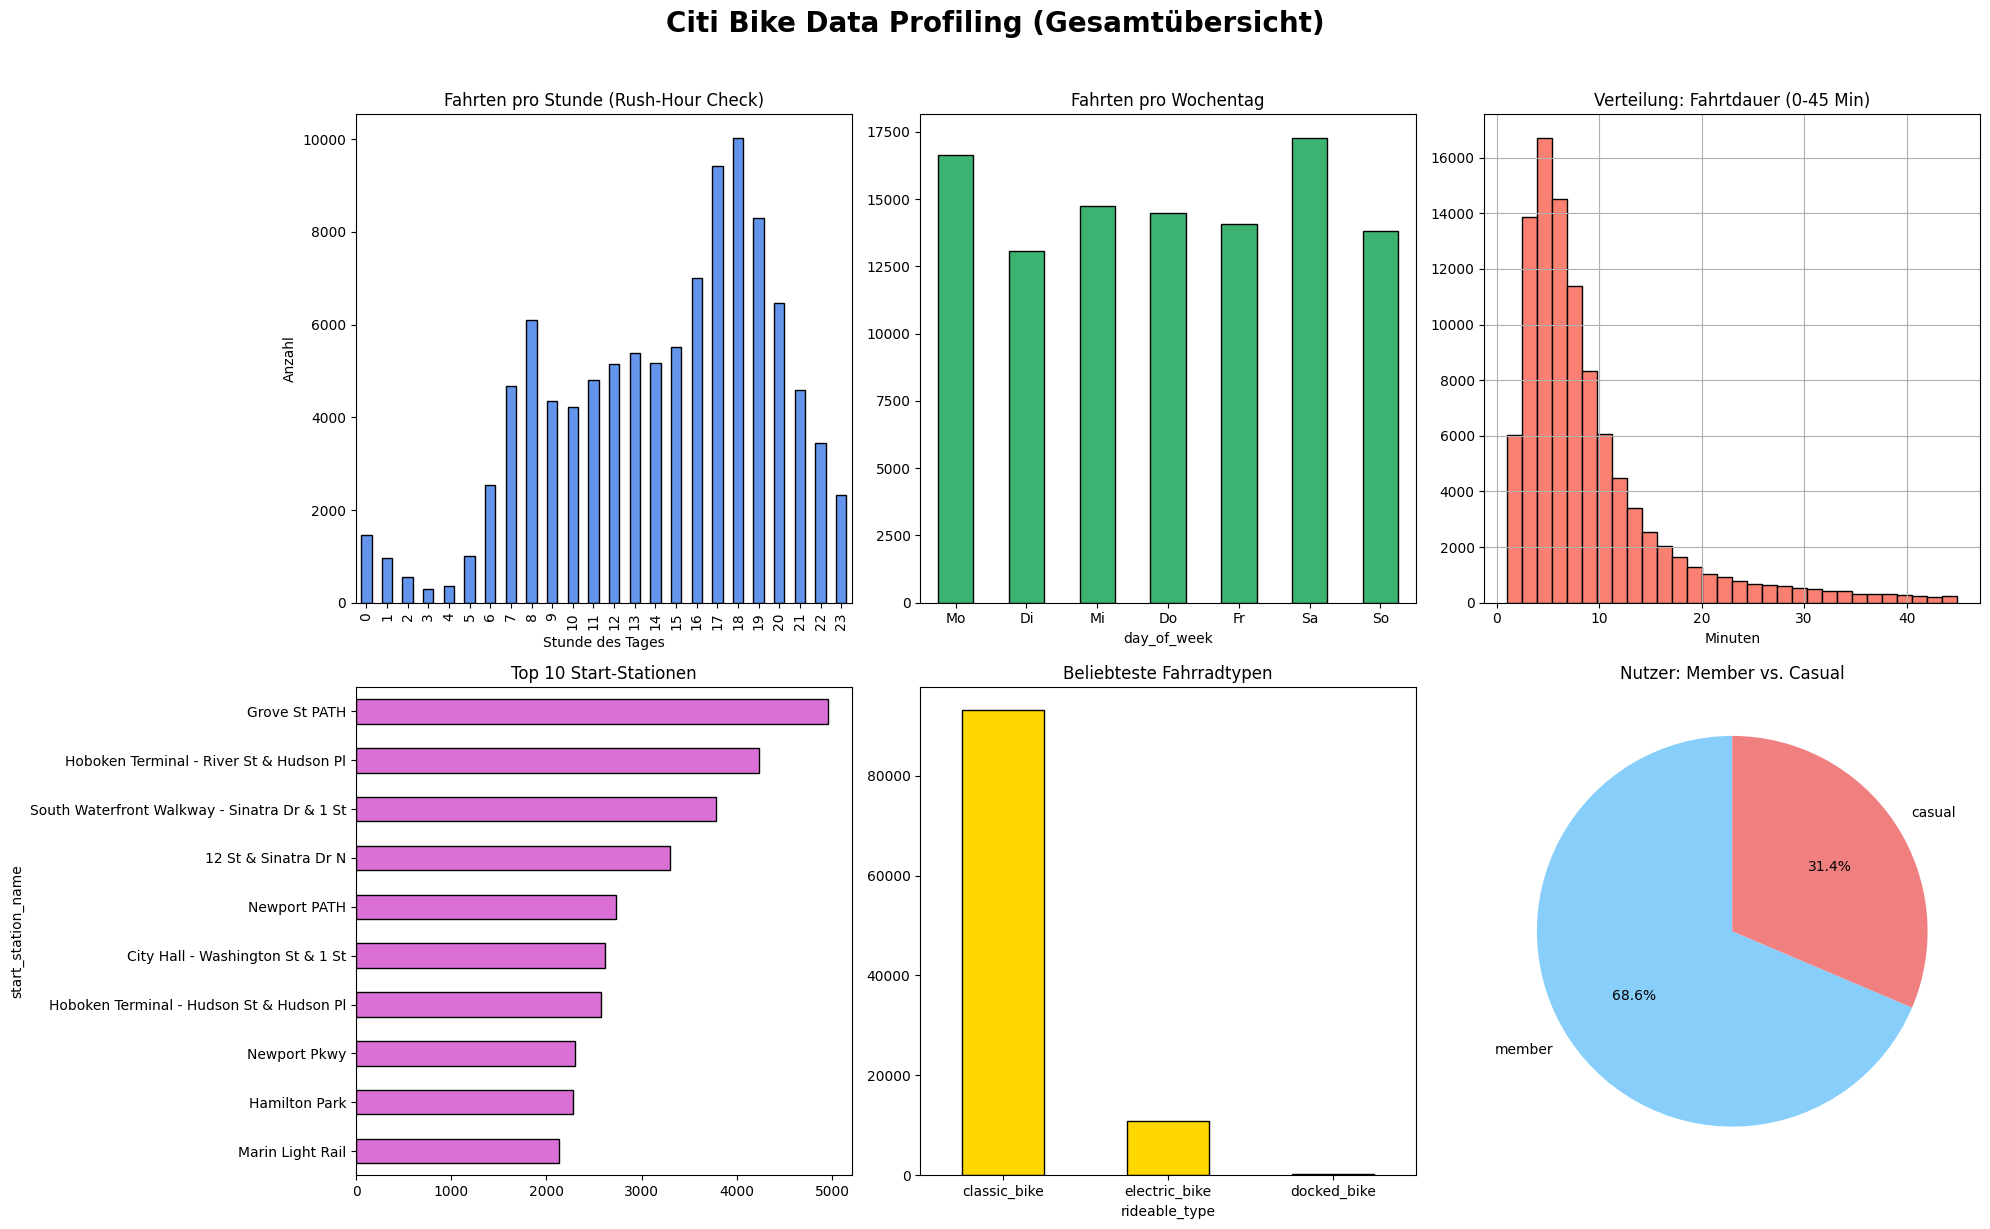


=== KONSISTENZ-CHECK DER KATEGORIEN ===
Gefundene User-Typen: <StringArray>
['member', 'casual']
Length: 2, dtype: str
Gefundene Bike-Typen: <StringArray>
['classic_bike', 'electric_bike', 'docked_bike']
Length: 3, dtype: str


In [12]:
import matplotlib.pyplot as plt

print("Generiere umfassendes Data Profiling...")

# 1. Wir extrahieren Stunde und Wochentag für tiefere Einblicke
df_citi['hour_of_day'] = df_citi['started_at'].dt.hour
# Wochentage als Zahlen (0=Montag, 6=Sonntag) für saubere Sortierung
df_citi['day_of_week'] = df_citi['started_at'].dt.dayofweek 

# 2. Wir bereiten das Raster vor: 2 Zeilen, 3 Spalten
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Citi Bike Data Profiling (Gesamtübersicht)', fontsize=20, fontweight='bold', y=1.02)

# --- Zeile 1 ---

# Diagramm 1: Fahrten nach Tageszeit (Wann ist Rush-Hour?)
df_citi['hour_of_day'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 0], color='cornflowerblue', edgecolor='black')
axes[0, 0].set_title('Fahrten pro Stunde (Rush-Hour Check)')
axes[0, 0].set_xlabel('Stunde des Tages')
axes[0, 0].set_ylabel('Anzahl')

# Diagramm 2: Fahrten nach Wochentag (Pendler vs. Touristen)
wochentage = ['Mo', 'Di', 'Mi', 'Do', 'Fr', 'Sa', 'So']
df_citi['day_of_week'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 1], color='mediumseagreen', edgecolor='black')
axes[0, 1].set_title('Fahrten pro Wochentag')
axes[0, 1].set_xticklabels(wochentage, rotation=0)

# Diagramm 3: Verteilung der Fahrtdauer (< 45 Min)
df_citi[df_citi['duration_minutes'] < 45]['duration_minutes'].hist(bins=30, ax=axes[0, 2], color='salmon', edgecolor='black')
axes[0, 2].set_title('Verteilung: Fahrtdauer (0-45 Min)')
axes[0, 2].set_xlabel('Minuten')

# --- Zeile 2 ---

# Diagramm 4: Top 10 Start-Stationen
df_citi['start_station_name'].value_counts().head(10).plot(kind='barh', ax=axes[1, 0], color='orchid', edgecolor='black')
axes[1, 0].set_title('Top 10 Start-Stationen')
axes[1, 0].invert_yaxis() # Die größte Station ganz nach oben

# Diagramm 5: Fahrrad-Typen
df_citi['rideable_type'].value_counts().plot(kind='bar', ax=axes[1, 1], color='gold', edgecolor='black')
axes[1, 1].set_title('Beliebteste Fahrradtypen')
axes[1, 1].tick_params(axis='x', rotation=0)

# Diagramm 6: Nutzer-Typen
df_citi['member_casual'].value_counts().plot(kind='pie', ax=axes[1, 2], autopct='%1.1f%%', colors=['lightskyblue', 'lightcoral'], startangle=90)
axes[1, 2].set_title('Nutzer: Member vs. Casual')
axes[1, 2].set_ylabel('') # Versteckt das hässliche Y-Label beim Pie-Chart

# Layout aufräumen und anzeigen
plt.tight_layout()
plt.show()

# --- Text-Check ---
print("\n=== KONSISTENZ-CHECK DER KATEGORIEN ===")
print(f"Gefundene User-Typen: {df_citi['member_casual'].unique()}")
print(f"Gefundene Bike-Typen: {df_citi['rideable_type'].unique()}")